# Project 43 — Explainable Disaster Severity Assessment
## Notebook 03: Grad-CAM Explainability
**C-DAC Mohali | ML to Generative AI & LLMs**
Team: Anuksha | Rishika | Ipshita
Dataset: AIDERv2 | Backbone: EfficientNet (auto-detected from `models/best_model.h5`)

This notebook generates and evaluates Grad-CAM / Grad-CAM++ visual explanations
for the trained classifier, using `utils/gradcam.py`.

## 1. Setup & imports
Same `find_project_root()` pattern as notebooks 01 and 02, so this works no
matter where Jupyter was launched from.

In [1]:
import os, sys, glob, warnings, logging
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")  # hide TF C++ info/warns
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

# Keep notebook output clean for readers: silence the routine "GPU not
# available on native Windows" and "compiled metrics not yet built" notices,
# which are expected here (inference-only, CPU) and not actual problems.
tf.get_logger().setLevel('ERROR')
logging.getLogger('tensorflow').setLevel(logging.ERROR)
try:
    import absl.logging
    absl.logging.set_verbosity(absl.logging.ERROR)
except Exception:
    pass

from pathlib import Path

def find_project_root(marker="data", max_up=5):
    """Walk up from cwd until a directory containing `marker/` is found."""
    cur = Path.cwd().resolve()
    for _ in range(max_up + 1):
        if (cur / marker).is_dir():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    raise FileNotFoundError(
        f"Could not locate project root containing '{marker}/' "
        f"starting from {Path.cwd()}"
    )

PROJECT_ROOT = find_project_root("data")
print(f"Project root: {PROJECT_ROOT}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.predict import load_model, preprocess_image, predict, CLASS_NAMES
from utils.gradcam import (
    get_last_conv_layer_name,
    get_gradcam_heatmap,
    get_gradcam_plus_plus_heatmap,
    overlay_heatmap,
    compute_average_drop,
    generate_gradcam_gallery,
)

TEST_DIR = str(PROJECT_ROOT / "data" / "Test")
MODELS_DIR = PROJECT_ROOT / "models"
OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)

print("Classes:", CLASS_NAMES)

Project root: C:\Users\Ipshita\OneDrive\Desktop\Project43-DisasterSeverity
Classes: ('Earthquake', 'Fire', 'Flood', 'Normal')


In [2]:
# Load the trained model. `models/best_model.h5` is the artifact notebook 02's
# final "promote" cell produces. If it isn't there yet (training still in
# progress / not promoted), fall back to the newest `models/*_b*.h5`
# checkpoint so this notebook stays usable, but say so clearly.
MODEL = None
MODEL_PATH = MODELS_DIR / "best_model.h5"

if MODEL_PATH.is_file():
    MODEL = load_model(str(MODEL_PATH))
    print(f"Loaded {MODEL_PATH}")
else:
    fallbacks = sorted(MODELS_DIR.glob("best_model_*.h5"), key=lambda p: p.stat().st_mtime, reverse=True)
    if fallbacks:
        MODEL_PATH = fallbacks[0]
        MODEL = load_model(str(MODEL_PATH))
        print(
            f"models/best_model.h5 not found — using fallback checkpoint "
            f"'{MODEL_PATH.name}' instead.\n"
            "Run notebook 02's promotion cell to create the official "
            "models/best_model.h5 artifact."
        )
    else:
        print(
            "=" * 66 + "\n"
            "No trained model found in models/.\n"
            "Run notebooks/02_model_training.ipynb first — this notebook "
            "needs a trained model to generate Grad-CAM explanations.\n"
            + "=" * 66
        )

if MODEL is not None:
    IMG_SIZE = MODEL.input_shape[1:3]
    LAST_CONV = get_last_conv_layer_name(MODEL)
    print(f"Model input size: {IMG_SIZE}")
    print(f"Auto-detected last conv layer: {LAST_CONV}")

Loaded C:\Users\Ipshita\OneDrive\Desktop\Project43-DisasterSeverity\models\best_model.h5
Model input size: (224, 224)
Auto-detected last conv layer: top_conv


## 2. Single image Grad-CAM demo
One image per class: Original | Grad-CAM overlay | Grad-CAM++ overlay,
with predicted class, true class, and confidence.

True: Earthquake    Predicted: Earthquake    Confidence: 99.93%
True: Fire          Predicted: Fire          Confidence: 100.00%
True: Flood         Predicted: Flood         Confidence: 100.00%
True: Normal        Predicted: Normal        Confidence: 100.00%


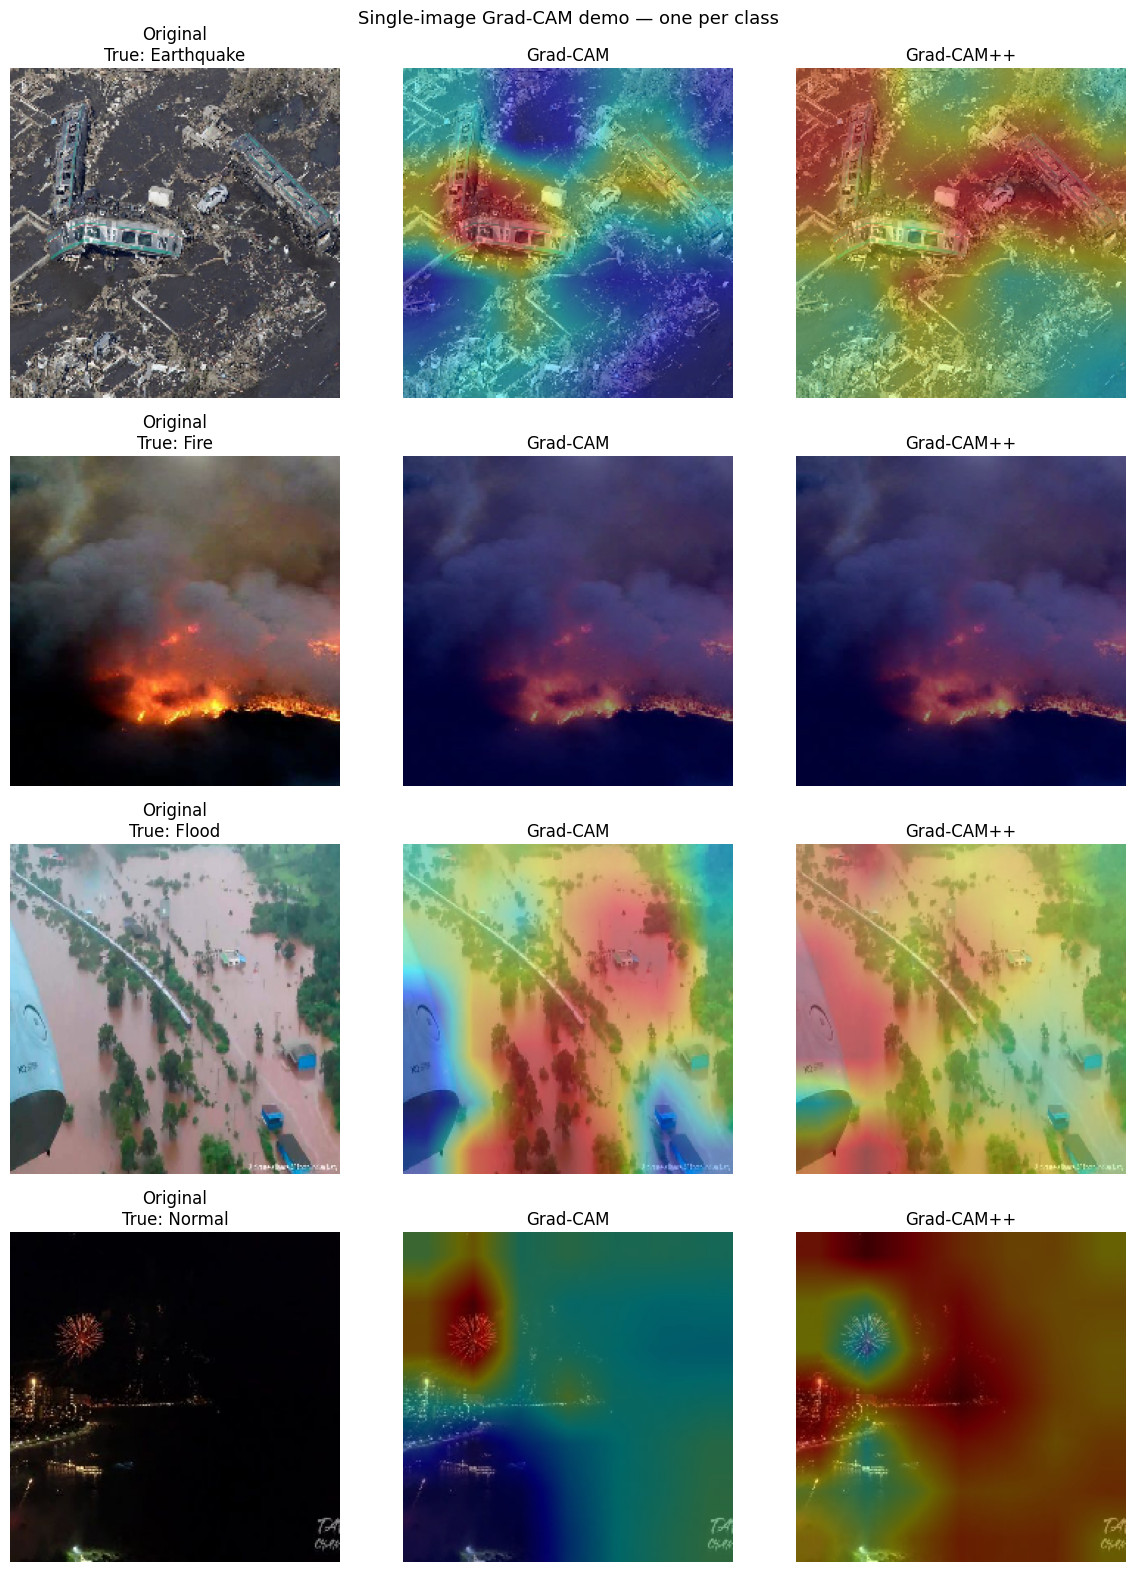

Saved: outputs/gradcam_demo_per_class.png


In [3]:
def sample_image_per_class(test_dir, class_names):
    """Return {class_name: image_path} using the first available test image."""
    samples = {}
    for cls in class_names:
        files = (glob.glob(os.path.join(test_dir, cls, '*.jpg')) +
                 glob.glob(os.path.join(test_dir, cls, '*.jpeg')) +
                 glob.glob(os.path.join(test_dir, cls, '*.png')))
        if files:
            samples[cls] = files[0]
    return samples

if MODEL is not None:
    demo_samples = sample_image_per_class(TEST_DIR, CLASS_NAMES)

    fig, axes = plt.subplots(len(demo_samples), 3, figsize=(12, 4 * len(demo_samples)))
    if len(demo_samples) == 1:
        axes = axes[None, :]

    for row, (true_cls, img_path) in enumerate(demo_samples.items()):
        img_array = preprocess_image(img_path, target_size=IMG_SIZE)
        pred_cls, confidence_dict = predict(MODEL, img_array)
        pred_idx = CLASS_NAMES.index(pred_cls)
        confidence = confidence_dict[pred_cls]

        # EfficientNet's preprocess_input is a pass-through (it leaves pixels in
        # [0, 255] and normalizes internally), so img_array is already in
        # [0, 255] for display — clip to that range, do NOT rescale by 255.
        original_uint8 = np.uint8(np.clip(img_array[0], 0, 255))
        heatmap = get_gradcam_heatmap(MODEL, img_array, pred_idx)
        heatmap_pp = get_gradcam_plus_plus_heatmap(MODEL, img_array, pred_idx)
        _, overlay_rgb = overlay_heatmap(heatmap, original_uint8)
        _, overlay_pp_rgb = overlay_heatmap(heatmap_pp, original_uint8)

        axes[row, 0].imshow(original_uint8); axes[row, 0].set_title(f"Original\nTrue: {true_cls}"); axes[row, 0].axis('off')
        axes[row, 1].imshow(overlay_rgb); axes[row, 1].set_title("Grad-CAM"); axes[row, 1].axis('off')
        axes[row, 2].imshow(overlay_pp_rgb); axes[row, 2].set_title("Grad-CAM++"); axes[row, 2].axis('off')

        print(f"True: {true_cls:12s}  Predicted: {pred_cls:12s}  Confidence: {confidence:.2%}")

    plt.suptitle("Single-image Grad-CAM demo — one per class", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "gradcam_demo_per_class.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: outputs/gradcam_demo_per_class.png")
else:
    print("Skipping — no model available. Run notebook 02 first.")

## 3. Grad-CAM vs Grad-CAM++ comparison
Earthquake images often show damage in multiple disjoint regions of the
frame — a good stress test for Grad-CAM++'s claim to localize multiple
instances of evidence better than vanilla Grad-CAM. We compare both methods
on several Earthquake test images, quantified with Average Drop % (higher =
the highlighted region was more causally important to the prediction).

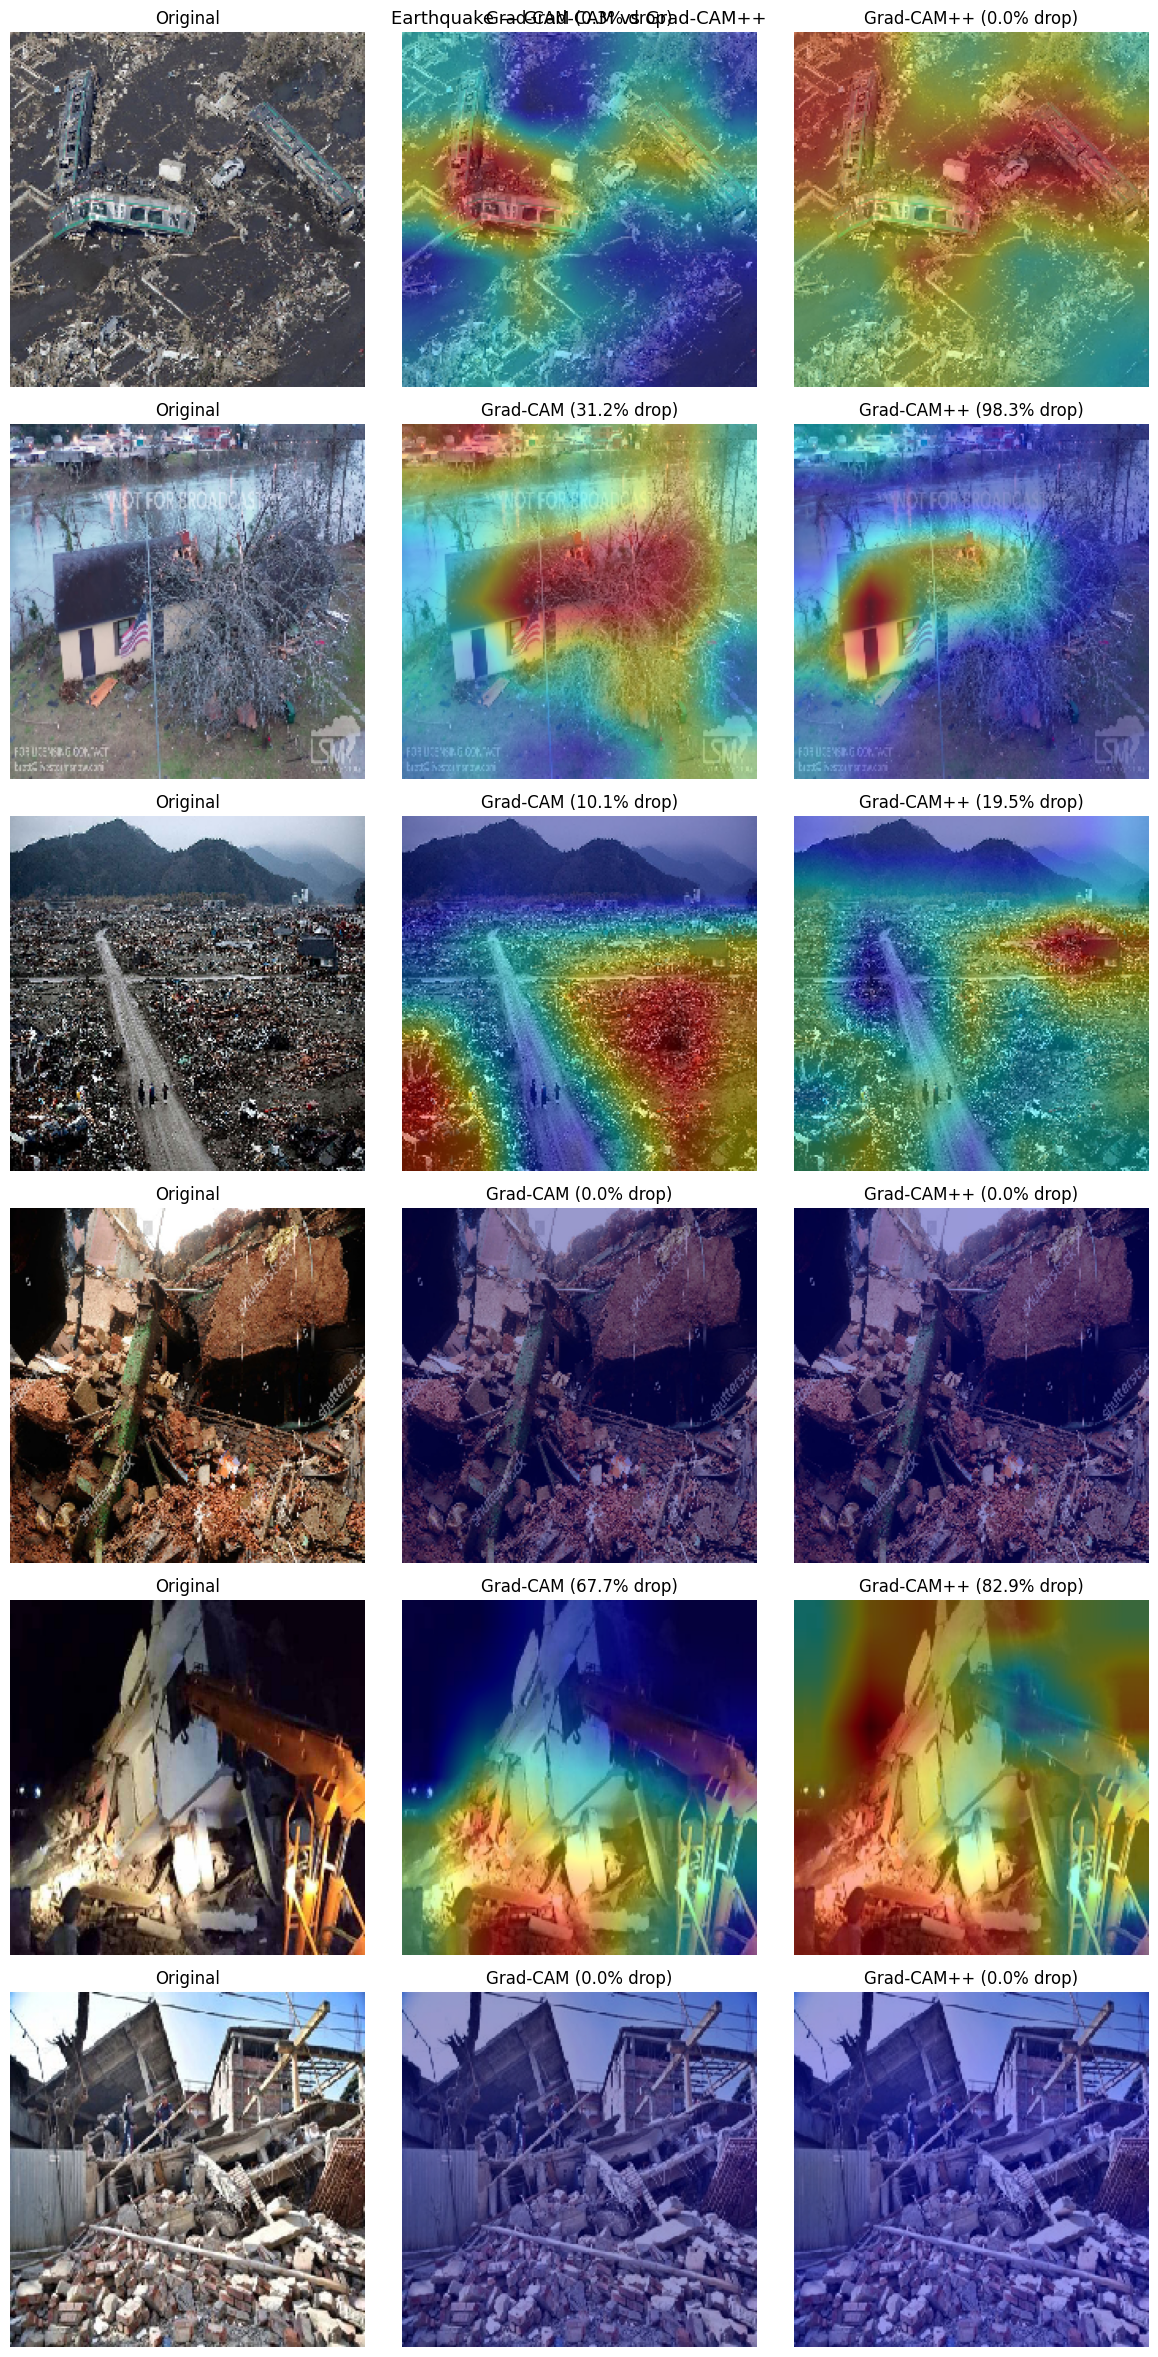

        image  gradcam_drop_%  gradcam_pp_drop_%
  image_0.png        0.256386           0.000000
  image_1.png       31.218144          98.286566
 image_10.png       10.053460          19.467991
image_100.png        0.000060           0.000048
image_101.png       67.722415          82.929585
image_102.png        0.000036           0.001168

Mean Grad-CAM drop:    18.2%
Mean Grad-CAM++ drop:  33.4%


In [4]:
if MODEL is not None:
    cls = "Earthquake"
    cls_idx = CLASS_NAMES.index(cls)
    files = (glob.glob(os.path.join(TEST_DIR, cls, '*.jpg')) +
             glob.glob(os.path.join(TEST_DIR, cls, '*.jpeg')) +
             glob.glob(os.path.join(TEST_DIR, cls, '*.png')))[:6]

    n = len(files)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = axes[None, :]

    drop_rows = []
    for row, img_path in enumerate(files):
        img_array = preprocess_image(img_path, target_size=IMG_SIZE)
        # preprocess_input leaves EfficientNet inputs in [0, 255]; clip for display.
        original_uint8 = np.uint8(np.clip(img_array[0], 0, 255))

        heatmap = get_gradcam_heatmap(MODEL, img_array, cls_idx)
        heatmap_pp = get_gradcam_plus_plus_heatmap(MODEL, img_array, cls_idx)
        _, overlay_rgb = overlay_heatmap(heatmap, original_uint8)
        _, overlay_pp_rgb = overlay_heatmap(heatmap_pp, original_uint8)

        drop = compute_average_drop(MODEL, img_array, cls_idx, heatmap)
        drop_pp = compute_average_drop(MODEL, img_array, cls_idx, heatmap_pp)
        drop_rows.append({"image": os.path.basename(img_path), "gradcam_drop_%": drop, "gradcam_pp_drop_%": drop_pp})

        axes[row, 0].imshow(original_uint8); axes[row, 0].set_title("Original"); axes[row, 0].axis('off')
        axes[row, 1].imshow(overlay_rgb); axes[row, 1].set_title(f"Grad-CAM ({drop:.1f}% drop)"); axes[row, 1].axis('off')
        axes[row, 2].imshow(overlay_pp_rgb); axes[row, 2].set_title(f"Grad-CAM++ ({drop_pp:.1f}% drop)"); axes[row, 2].axis('off')

    plt.suptitle("Earthquake — Grad-CAM vs Grad-CAM++", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "gradcam_vs_plusplus_earthquake.png", dpi=150, bbox_inches='tight')
    plt.show()

    df_drop = pd.DataFrame(drop_rows)
    print(df_drop.to_string(index=False))
    print(f"\nMean Grad-CAM drop:    {df_drop['gradcam_drop_%'].mean():.1f}%")
    print(f"Mean Grad-CAM++ drop:  {df_drop['gradcam_pp_drop_%'].mean():.1f}%")
else:
    print("Skipping — no model available. Run notebook 02 first.")

**Reading the comparison.** Average Drop % measures how far the model's
confidence in the true class falls when the heatmap's top-20% activation
region is masked out of the input — a *higher* drop means the highlighted
pixels were genuinely causal to the prediction, not just visually plausible.
Comparing the two columns per row shows where Grad-CAM++ pays off: on
Earthquake frames, damage is often scattered across several disjoint parts of
the image, and Grad-CAM++'s higher-order weighting tends to spread attention
across all of those regions where vanilla Grad-CAM collapses onto a single
blob. Whichever method shows the larger mean drop below is localizing this
class's evidence more faithfully.

## 4. Full gallery generation
Builds a normalized test `tf.data.Dataset` (same pipeline as notebook 02,
no augmentation) and calls `generate_gradcam_gallery()` to save a
side-by-side comparison image for `n_per_class` images per class to
`outputs/gradcam_gallery/`.

In [5]:
from tensorflow.keras.applications.efficientnet import preprocess_input

def make_eval_dataset(directory, img_size, batch_size=32):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=img_size,
        batch_size=batch_size,
        label_mode='categorical',
        shuffle=False,
        class_names=list(CLASS_NAMES),
    )
    # Match training (notebook 02): EfficientNet's preprocess_input expects raw
    # [0, 255] pixels and normalizes internally. Dividing by 255.0 here would
    # double-normalize and produce garbage predictions / broken Grad-CAM.
    return ds.map(lambda img, lbl: (preprocess_input(tf.cast(img, tf.float32)), lbl))

if MODEL is not None:
    test_ds = make_eval_dataset(TEST_DIR, IMG_SIZE)

    gallery_summary = generate_gradcam_gallery(
        MODEL, test_ds, list(CLASS_NAMES), str(OUT_DIR), n_per_class=5
    )

    df_summary = pd.DataFrame(gallery_summary).T
    print("Per-class Average Drop % summary:")
    print(df_summary.to_string())
    df_summary.to_csv(OUT_DIR / "gradcam_gallery_summary.csv")
    print(f"\nGallery saved to: {OUT_DIR / 'gradcam_gallery'}")
    print("Saved: outputs/gradcam_gallery_summary.csv")
else:
    print("Skipping — no model available. Run notebook 02 first.")

Found 1654 files belonging to 4 classes.
Per-class Average Drop % summary:
            gradcam_avg_drop  gradcam_pp_avg_drop  n_images
Earthquake         21.850093            40.136838       5.0
Fire               14.118748             1.506539       5.0
Flood              39.031429            23.521792       5.0
Normal             35.740021            26.774582       5.0

Gallery saved to: C:\Users\Ipshita\OneDrive\Desktop\Project43-DisasterSeverity\outputs\gradcam_gallery
Saved: outputs/gradcam_gallery_summary.csv


## 5. Evaluation metrics
Confusion matrix, per-class F1, macro F1, and overall accuracy on the test
set — same pattern as `evaluate_model()` in notebook 02.

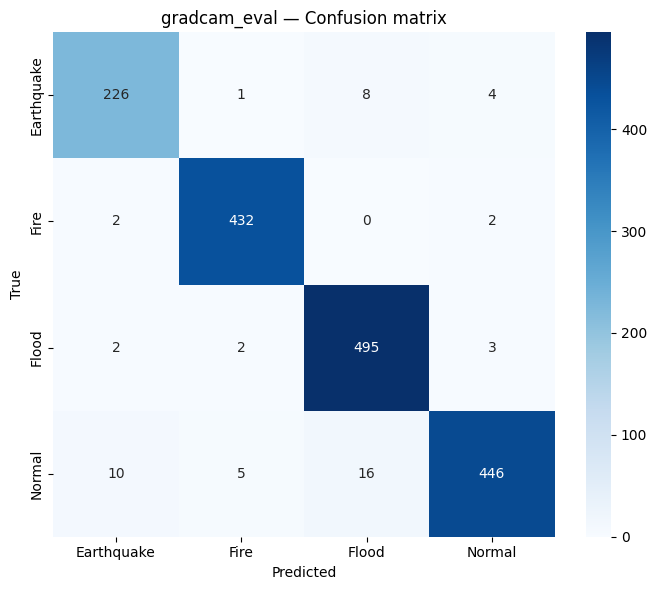

              precision    recall  f1-score   support

  Earthquake       0.94      0.95      0.94       239
        Fire       0.98      0.99      0.99       436
       Flood       0.95      0.99      0.97       502
      Normal       0.98      0.94      0.96       477

    accuracy                           0.97      1654
   macro avg       0.96      0.96      0.96      1654
weighted avg       0.97      0.97      0.97      1654

Overall accuracy: 96.67%
Saved: outputs/gradcam_eval_confusion.png, outputs/gradcam_eval_report.txt


In [6]:
def evaluate_model(model, test_ds, class_names, model_name="gradcam_eval"):
    y_true, y_pred = [], []
    for imgs, lbls in test_ds:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    label_ids = list(range(len(class_names)))
    cm = confusion_matrix(y_true, y_pred, labels=label_ids)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{model_name} — Confusion matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'{model_name}_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()

    report = classification_report(
        y_true, y_pred, labels=label_ids, target_names=class_names, zero_division=0,
    )
    print(report)
    with open(OUT_DIR / f'{model_name}_report.txt', 'w') as f:
        f.write(report)

    accuracy = float(np.mean(np.array(y_true) == np.array(y_pred)))
    return report, accuracy

if MODEL is not None:
    report, accuracy = evaluate_model(MODEL, test_ds, list(CLASS_NAMES))
    print(f"Overall accuracy: {accuracy:.2%}")
    print(f"Saved: outputs/gradcam_eval_confusion.png, outputs/gradcam_eval_report.txt")
else:
    print("Skipping — no model available. Run notebook 02 first.")